In [1]:
import random
from pathlib import Path
import numpy as np
import pd
import torch
from torchvision import transforms
from torch.utils.data import DataLoader

from src.dataset._balance_class_subset import BalancedClassSubset
from src.dataset.tiny_imagenet_dataset import TinyImageNetLoader

print("PyTorch:", torch.__version__)

PyTorch: 2.13.0


In [2]:
SEED = 42

NUM_CLASSES = 20
SELECTED_CLASSES = list(range(NUM_CLASSES))
TRAIN_IMAGES_PER_CLASS = 500
VAL_IMAGES_PER_CLASS = 50

BATCH_SIZE = 32
NUM_WORKERS = 0
EPOCHS = 90

MAX_LR = 0.06
SGD_WEIGHT_DECAY = 5e-4
LABEL_SMOOTHING = 0.10

FEATURE_DROPOUT = 0.40
BLOCK3_DROPOUT = 0.15
BLOCK4_DROPOUT = 0.25

HARD_WEIGHT_STRENGTH = 0.25
HARD_WEIGHT_MIN = 1.00
HARD_WEIGHT_MAX = 1.50

EARLY_STOPPING_PATIENCE = 30
SAVE_PATH = "best_standard_cnn_384_hard_boost_ce_20class.pth"

means = [0.48022549245655144, 0.4480585117404561, 0.397521028501032]
stds = [0.2661645123876411, 0.2582361193999296, 0.2718131688966652]

CLASS_NAMES = [
    "goldfish",
    "European fire salamander",
    "bullfrog",
    "tailed frog",
    "American alligator",
    "boa constrictor",
    "trilobite",
    "scorpion",
    "black widow",
    "tarantula",
    "centipede",
    "goose",
    "koala",
    "jellyfish",
    "brain coral",
    "snail",
    "slug",
    "sea slug",
    "American lobster",
    "spiny lobster"
]

print("Batch size:", BATCH_SIZE)
print("Hard-weight strength:", HARD_WEIGHT_STRENGTH)
print("Hard-weight range:", (HARD_WEIGHT_MIN, HARD_WEIGHT_MAX))

Batch size: 32
Hard-weight strength: 0.25
Hard-weight range: (1.0, 1.5)


In [3]:
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")

print("Device:", DEVICE)

Device: mps


In [4]:
def convert_to_rgb(image):
    return image.convert("RGB")


# train_transform = transforms.Compose([
#     transforms.Lambda(convert_to_rgb),
#     transforms.RandomCrop(64, padding=4, padding_mode="reflect"),
#     transforms.RandomHorizontalFlip(p=0.5),
#     transforms.RandomVerticalFlip(p=0.1),
#     # transforms.RandAugment(num_ops=2, magnitude=7),
#     transforms.ColorJitter(
#         brightness=0.10,
#         contrast=0.10,
#         saturation=0.10,
#         hue=0.02
#     ),  # or RandAugment or RandomErasing
#     transforms.ToTensor(),
#     transforms.Normalize(mean=means, std=stds),
#     transforms.RandomErasing(
#         p=0.10,
#         scale=(0.01, 0.05),
#         ratio=(0.7, 1.4),
#         value="random"
#     )
# ])

train_transform = transforms.Compose([
    transforms.Lambda(convert_to_rgb),
    transforms.RandomCrop(64, padding=4, padding_mode="reflect"),
    transforms.RandomHorizontalFlip(p=0.5),

    transforms.AugMix(
        severity=3,
        mixture_width=3,
        chain_depth=-1,
        alpha=1.0
    ),

    transforms.ToTensor(),
    transforms.Normalize(mean=means, std=stds)
])

test_transform = transforms.Compose([
    transforms.Lambda(convert_to_rgb),
    transforms.ToTensor(),
    transforms.Normalize(mean=means, std=stds)
])

In [5]:
train_dataset, val_dataset, _, _ = TinyImageNetLoader(
    seed=SEED, root=Path("data/tiny_imagenet"),
    train_transform=train_transform,
    test_transform=test_transform).load()
train_eval_dataset, _, _, _ = TinyImageNetLoader(seed=SEED, root=Path("data/tiny_imagenet"),
                                                 train_transform=val_dataset.transform).load()

print("Full train dataset:", len(train_dataset))
print("Full validation dataset:", len(val_dataset))
print("Full clean train-eval dataset:", len(train_eval_dataset))

Full train dataset: 100000
Full validation dataset: 10000
Full clean train-eval dataset: 100000


In [6]:
train_subset = BalancedClassSubset(train_dataset, SELECTED_CLASSES, TRAIN_IMAGES_PER_CLASS, seed=SEED)
train_eval_subset = BalancedClassSubset(train_eval_dataset, SELECTED_CLASSES, TRAIN_IMAGES_PER_CLASS, seed=SEED)
val_subset = BalancedClassSubset(val_dataset, SELECTED_CLASSES, VAL_IMAGES_PER_CLASS, seed=SEED + 1)

print("Same selected training samples:", train_subset.samples == train_eval_subset.samples)
print("Selected classes:", len(SELECTED_CLASSES))
print("Training images:", len(train_subset))
print("Clean train-eval images:", len(train_eval_subset))
print("Validation images:", len(val_subset))

Same selected training samples: True
Selected classes: 20
Training images: 10000
Clean train-eval images: 10000
Validation images: 1000


In [7]:
generator = torch.Generator()
generator.manual_seed(SEED)
persistent_workers = NUM_WORKERS > 0

train_loader = DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=False, generator=generator,
                          num_workers=NUM_WORKERS, persistent_workers=persistent_workers)
train_eval_loader = DataLoader(train_eval_subset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS,
                               persistent_workers=persistent_workers)
val_loader = DataLoader(val_subset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS,
                        persistent_workers=persistent_workers)

print("Training batches:", len(train_loader))
print("Clean train-eval batches:", len(train_eval_loader))
print("Validation batches:", len(val_loader))

Training batches: 313
Clean train-eval batches: 313
Validation batches: 32


In [8]:
import matplotlib.pyplot as plt
import torch


def show_image(images, labels, num_show, name=''):
    MEAN_T = torch.tensor(means).view(3, 1, 1)
    STD_T = torch.tensor(stds).view(3, 1, 1)

    def denormalize(image):
        image = image.cpu()
        image = image * STD_T + MEAN_T
        return image.clamp(0, 1)

    plt.figure(figsize=(16, 10))

    for i in range(min(num_show, len(images))):
        image = denormalize(images[i])
        image = image.permute(1, 2, 0).numpy()

        plt.subplot(4, 5, i + 1)
        plt.imshow(image)
        plt.title(CLASS_NAMES[int(labels[i])], fontsize=9)
        plt.axis("off")

    plt.suptitle(f'{name}', fontsize=18, fontweight="bold")
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

In [9]:
NUM_SHOW = 10

train_iter = iter(train_loader)
val_iter = iter(val_loader)

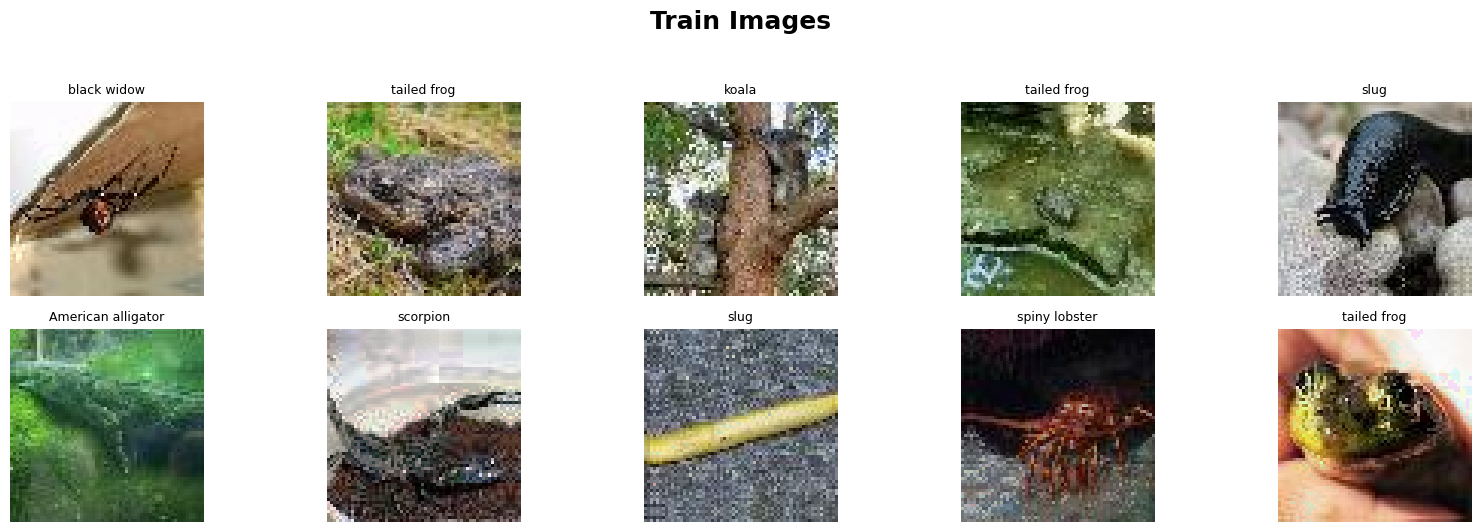

In [10]:
images, labels = next(train_iter)
show_image(images, labels, NUM_SHOW, name='Train Images')

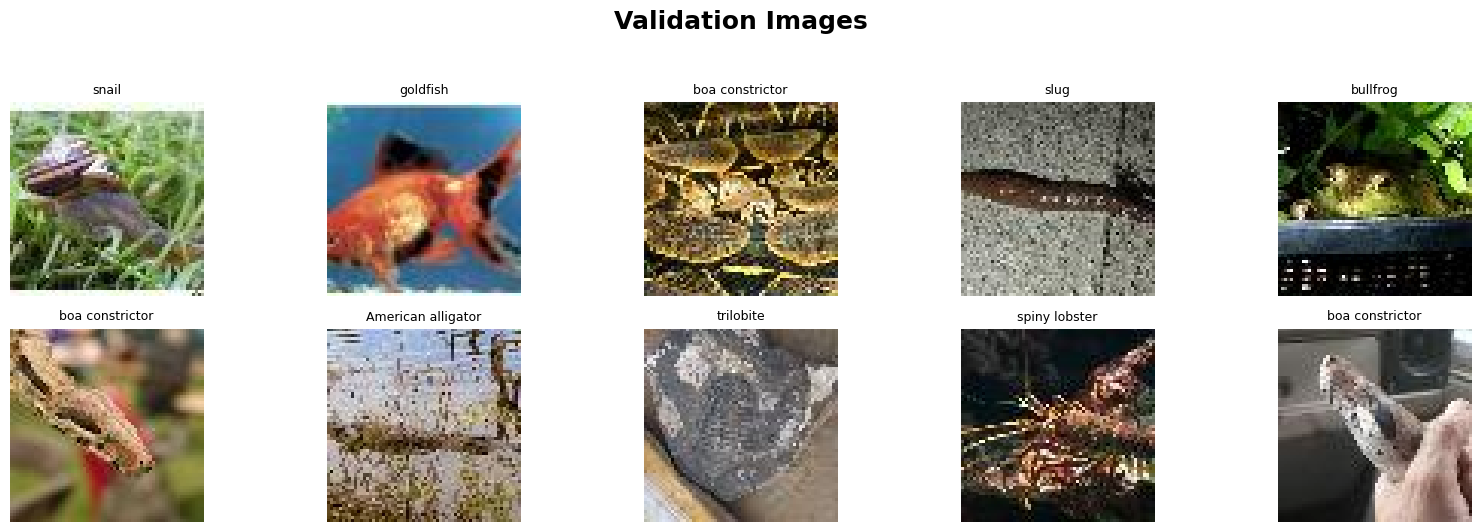

In [11]:
images, labels = next(val_iter)
show_image(images, labels, NUM_SHOW, name='Validation Images')

# From here

In [14]:
from pathlib import Path

TINY_ROOT = Path("./data/tiny_imagenet/tiny-imagenet-200")

# --------------------------------------------------
# Read WordNet ID -> readable class name
# --------------------------------------------------
wnid_to_name = {}

with open(TINY_ROOT / "words.txt", "r") as f:
    for line in f:
        wnid, names = line.strip().split("\t", 1)

        # Use first class name when multiple synonyms exist
        wnid_to_name[wnid] = names.split(",")[0].strip()


# --------------------------------------------------
# Get actual class order from dataset
# --------------------------------------------------
base_train_dataset = train_dataset

while hasattr(base_train_dataset, "dataset"):
    base_train_dataset = base_train_dataset.dataset

CLASS_WNIDS = base_train_dataset.classes


# --------------------------------------------------
# Full 200 class names in correct label order
# --------------------------------------------------
CLASS_NAMES = [
    wnid_to_name[wnid]
    for wnid in CLASS_WNIDS
]


print("Total classes:", len(CLASS_NAMES))

for class_id, class_name in enumerate(CLASS_NAMES):
    print(f"{class_id:03d}: {class_name}")

Total classes: 200
000: goldfish
001: European fire salamander
002: bullfrog
003: tailed frog
004: American alligator
005: boa constrictor
006: trilobite
007: scorpion
008: black widow
009: tarantula
010: centipede
011: goose
012: koala
013: jellyfish
014: brain coral
015: snail
016: slug
017: sea slug
018: American lobster
019: spiny lobster
020: black stork
021: king penguin
022: albatross
023: dugong
024: Chihuahua
025: Yorkshire terrier
026: golden retriever
027: Labrador retriever
028: German shepherd
029: standard poodle
030: tabby
031: Persian cat
032: Egyptian cat
033: cougar
034: lion
035: brown bear
036: ladybug
037: fly
038: bee
039: grasshopper
040: walking stick
041: cockroach
042: mantis
043: dragonfly
044: monarch
045: sulphur butterfly
046: sea cucumber
047: guinea pig
048: hog
049: ox
050: bison
051: bighorn
052: gazelle
053: Arabian camel
054: orangutan
055: chimpanzee
056: baboon
057: African elephant
058: lesser panda
059: abacus
060: academic gown
061: altar
062: a